In [16]:
!pip install -q torch torchvision scikit-image matplotlib seaborn

import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

IMG_SIZE, BATCH_SIZE, EPOCHS, LR, NUM_WORKERS = 28, 4, 100, 1e-3, 2
NOISE_LEVELS = [0.0, 0.05, 0.10]

print(f"Device: {DEVICE} | IMG:{IMG_SIZE} | BS:{BATCH_SIZE} | EP:{EPOCHS} | LR:{LR}")
print(f"Noise levels: {NOISE_LEVELS}")

Device: cuda | IMG:28 | BS:4 | EP:100 | LR:0.001
Noise levels: [0.0, 0.05, 0.1]


In [17]:
def filter_binary(dataset, class_a, class_b, max_per_class=None):
    targets = np.array(dataset.targets)
    idx_a   = np.where(targets == class_a)[0]
    idx_b   = np.where(targets == class_b)[0]
    if max_per_class:
        idx_a, idx_b = idx_a[:max_per_class], idx_b[:max_per_class]
    indices = np.concatenate([idx_a, idx_b])
    np.random.shuffle(indices)
    new_targets = targets.copy()
    new_targets[targets == class_a] = 0
    new_targets[targets == class_b] = 1
    dataset.targets = new_targets.tolist()
    return Subset(dataset, indices)

def split_dataset(dataset, train_n, val_n, test_n):
    leftover = len(dataset) - train_n - val_n - test_n
    return random_split(
        dataset, [train_n, val_n, test_n, leftover],
        generator=torch.Generator().manual_seed(SEED)
    )[:3]

def make_loaders(train_ds, val_ds, test_ds):
    return {
        'train': DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS),
        'val':   DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
        'test':  DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    }

def add_gaussian_noise(tensor, std):
    if std == 0.0:
        return tensor
    return torch.clamp(tensor + torch.randn_like(tensor) * std, -1., 1.)

print("Helpers ready")

Helpers ready


In [3]:
base_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


mnist_tr = filter_binary(datasets.MNIST('./data', train=True,  download=True, transform=base_tf), 3, 5, 3125)
mnist_te = filter_binary(datasets.MNIST('./data', train=False, download=True, transform=base_tf), 3, 5, 500)
mnist_loaders = make_loaders(*split_dataset(mnist_tr, 5000, 1250, 0)[:2], mnist_te)


fm_tr = filter_binary(datasets.FashionMNIST('./data', train=True,  download=True, transform=base_tf), 0, 1, 3125)
fm_te = filter_binary(datasets.FashionMNIST('./data', train=False, download=True, transform=base_tf), 0, 1, 500)
fmnist_loaders = make_loaders(*split_dataset(fm_tr, 5000, 1250, 0)[:2], fm_te)

print("MNIST & F-MNIST ready")


!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --unzip -q

class MRIBinaryDataset(Dataset):
    BENIGN    = {'notumor', 'no tumor'}
    MALIGNANT = {'glioma', 'meningioma', 'pituitary'}

    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples = []
        for ext in ('*.jpg', '*.png'):
            for p in Path(root).rglob(ext):
                folder = p.parent.name.lower().replace('_', ' ').replace('-', ' ')
                if any(b in folder for b in self.BENIGN):
                    self.samples.append((str(p), 0))
                elif any(m in folder for m in self.MALIGNANT):
                    self.samples.append((str(p), 1))
        np.random.shuffle(self.samples)
        labels = [s[1] for s in self.samples]
        print(f"MRI total:{len(self.samples)}  Benign:{labels.count(0)}  Malignant:{labels.count(1)}")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('L')
        return self.transform(img) if self.transform else img, label

mri_full = MRIBinaryDataset('/content', transform=base_tf)
mri_loaders = make_loaders(*split_dataset(mri_full, 2089, 653, 523))
print("MRI ready")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.87MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.48MB/s]
100%|██████████| 26.4M/26.4M [00:03<00:00, 8.03MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 171kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.13MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.3MB/s]

MNIST & F-MNIST ready


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
MRI total:7200  Benign:1800  Malignant:5400
MRI ready


In [4]:
class ClassicalCNN(nn.Module):
    def __init__(self, in_channels=1, img_size=28):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),          nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
        )
        flat = self.features(torch.zeros(1, in_channels, img_size, img_size)).numel()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 64), nn.ReLU(True), nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x): return self.classifier(self.features(x))


m = ClassicalCNN().to(DEVICE)
print(m)
print(f"\nParams: {sum(p.numel() for p in m.parameters() if p.requires_grad):,}")
print(f"Output: {tuple(m(torch.randn(4,1,28,28).to(DEVICE)).shape)}")

ClassicalCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

Params: 105,377
Output: (4, 1)


In [18]:
def run_epoch(model, loader, optimizer, criterion, train=True, noise_std=0.0):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs   = add_gaussian_noise(imgs, noise_std).to(DEVICE)
            labels = labels.float().unsqueeze(1).to(DEVICE)
            if train: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if train: loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += ((torch.sigmoid(out) >= 0.5).float() == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


def train_model(name, loaders, noise_std=0.0):
    print(f"\n{'='*55}\n  {name}  |  noise σ={noise_std}\n{'='*55}")
    model     = ClassicalCNN().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=7, factor=0.5)
    history   = {k: [] for k in ('train_loss', 'val_loss', 'train_acc', 'val_acc')}
    best_acc, best_state, stagnant = 0.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(model, loaders['train'], optimizer, criterion, train=True,  noise_std=noise_std)
        va_loss, va_acc = run_epoch(model, loaders['val'],   optimizer, criterion, train=False, noise_std=noise_std)
        for k, v in zip(history, [tr_loss, va_loss, tr_acc, va_acc]):
            history[k].append(v)
        scheduler.step(va_acc)
        if va_acc > best_acc:
            best_acc   = va_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            stagnant   = 0
        else:
            stagnant += 1
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Ep {epoch:3d} | train {tr_acc*100:.2f}% {tr_loss:.4f} | val {va_acc*100:.2f}% {va_loss:.4f}")
        if stagnant >= 15:
            print(f"  Early stop @ epoch {epoch}"); break

    model.load_state_dict(best_state)
    print(f"\n  Best val: {best_acc*100:.2f}%")
    return model, history

print("Training functions ready")
print("Training functions ready")

Training functions ready
Training functions ready


In [19]:
DS_CONFIG = {
    'MNIST':   mnist_loaders,
    'FMNIST':  fmnist_loaders,
    'MRI':     mri_loaders,
}

# Stores: trained_models['MNIST'][0.0] = model
#         histories['MNIST'][0.0]      = history
trained_models = {ds: {} for ds in DS_CONFIG}
histories      = {ds: {} for ds in DS_CONFIG}

for ds_name, loaders in DS_CONFIG.items():
    for std in NOISE_LEVELS:
        model, hist = train_model(f"{ds_name}", loaders, noise_std=std)
        trained_models[ds_name][std] = model
        histories[ds_name][std]      = hist
        torch.save(model.state_dict(), f"cnn_{ds_name}_noise{int(std*100)}.pt")
        print(f"Saved → cnn_{ds_name}_noise{int(std*100)}.pt")

print("\nAll models trained and saved.")


  MNIST  |  noise σ=0.0
  Ep   1 | train 88.84% 0.3762 | val 99.04% 0.2102
  Ep  10 | train 95.04% 0.1166 | val 99.28% 0.0343
  Ep  20 | train 95.58% 0.1060 | val 99.52% 0.0228
  Ep  30 | train 95.34% 0.1085 | val 99.52% 0.0388
  Early stop @ epoch 32

  Best val: 99.52%
Saved → cnn_MNIST_noise0.pt

  MNIST  |  noise σ=0.05
  Ep   1 | train 95.84% 0.1090 | val 98.72% 0.0386
  Ep  10 | train 99.68% 0.0117 | val 99.44% 0.0281
  Early stop @ epoch 18

  Best val: 99.52%
Saved → cnn_MNIST_noise5.pt

  MNIST  |  noise σ=0.1
  Ep   1 | train 97.12% 0.0742 | val 96.96% 0.0903
  Ep  10 | train 99.80% 0.0053 | val 99.68% 0.0108
  Ep  20 | train 99.98% 0.0006 | val 99.60% 0.0261
  Early stop @ epoch 25

  Best val: 99.68%
Saved → cnn_MNIST_noise10.pt

  FMNIST  |  noise σ=0.0
  Ep   1 | train 98.32% 0.0538 | val 99.36% 0.0334
  Ep  10 | train 99.84% 0.0049 | val 99.44% 0.0295
  Early stop @ epoch 19

  Best val: 99.52%
Saved → cnn_FMNIST_noise0.pt

  FMNIST  |  noise σ=0.05
  Ep   1 | train 98.

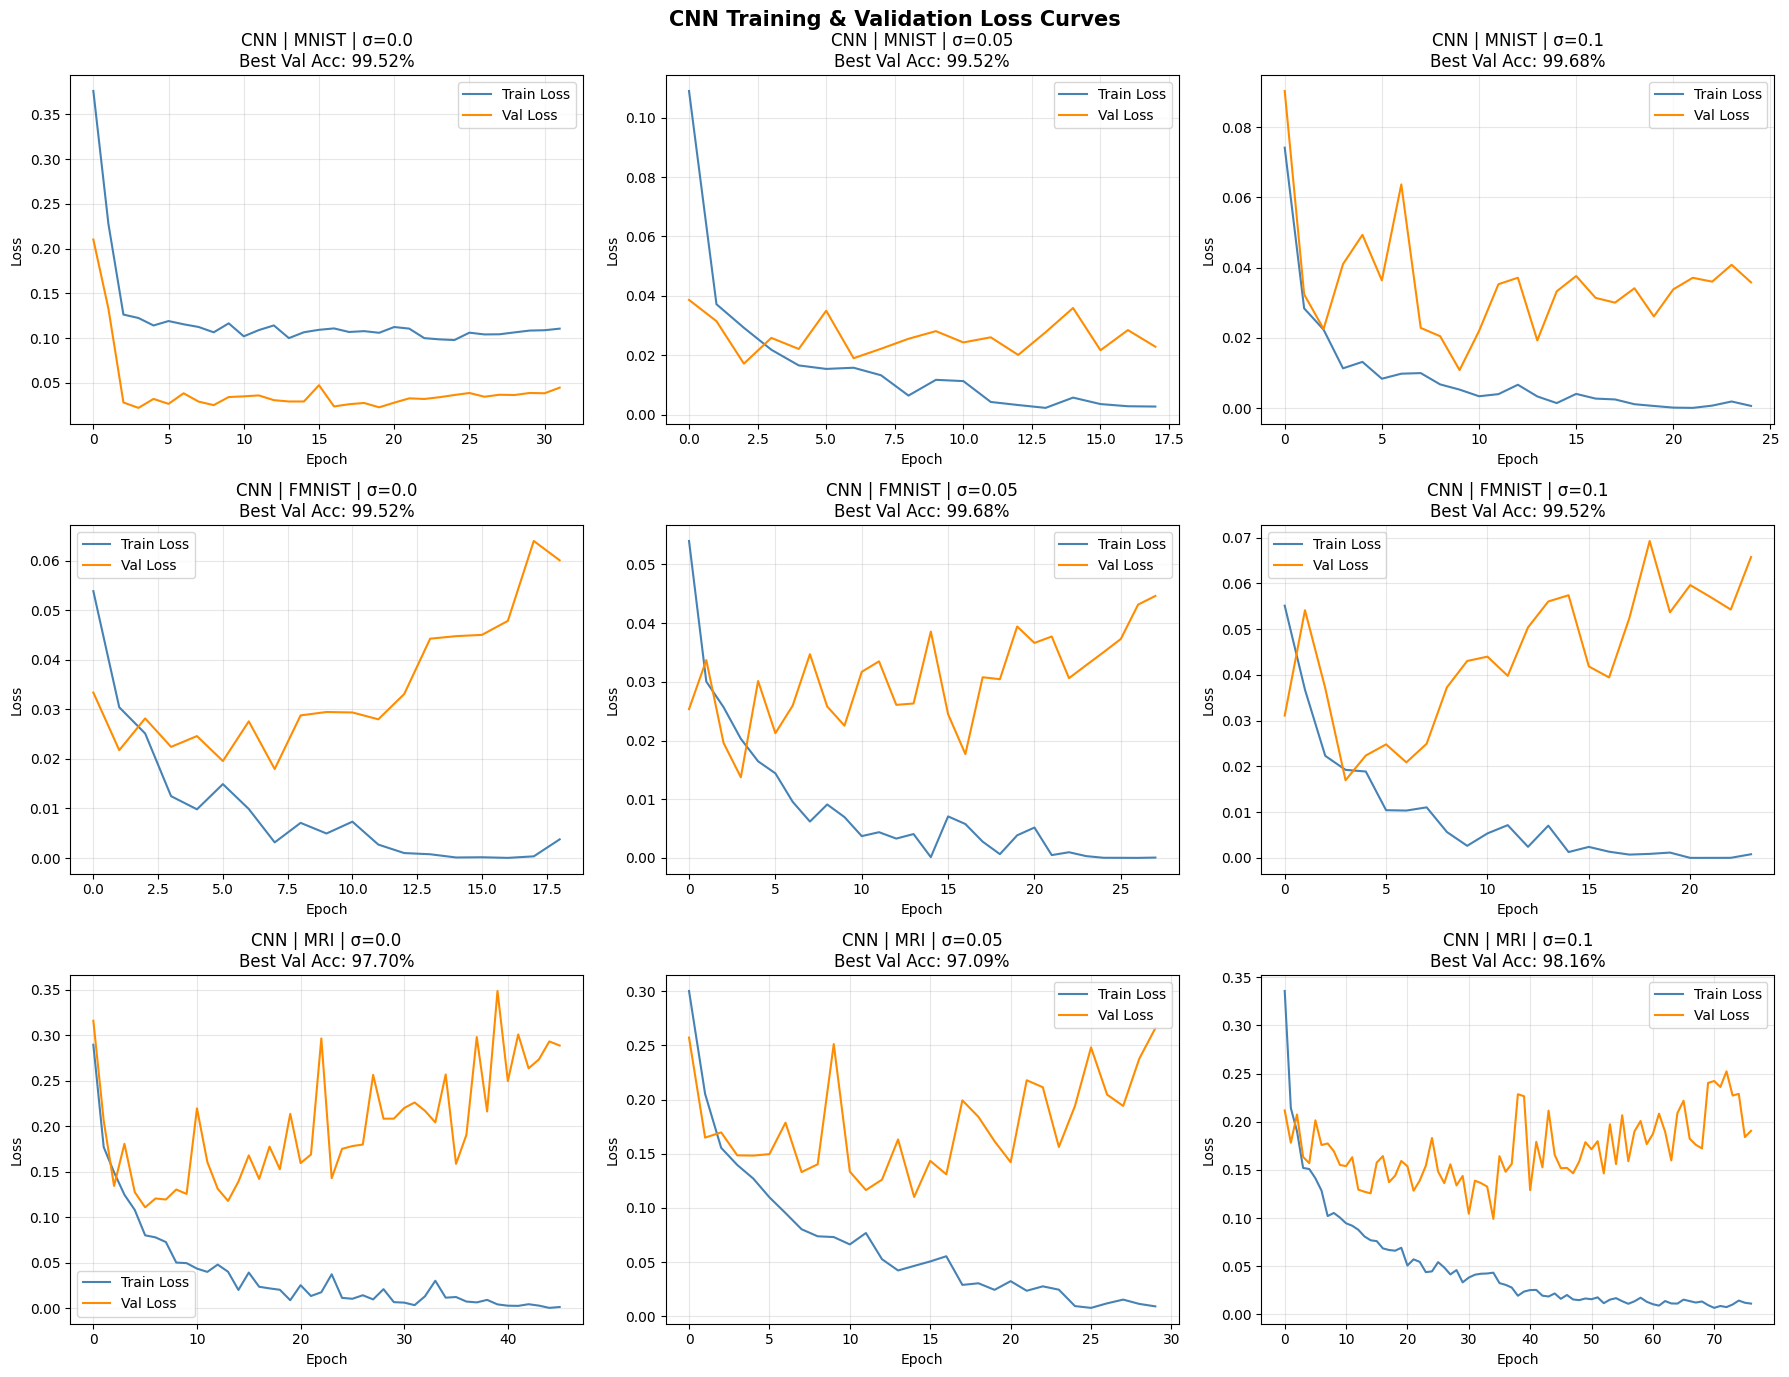

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('CNN Training & Validation Loss Curves', fontsize=15, fontweight='bold')

for row, ds_name in enumerate(DS_CONFIG):
    for col, std in enumerate(NOISE_LEVELS):
        hist = histories[ds_name][std]
        ax   = axes[row][col]
        ax.plot(hist['train_loss'], label='Train Loss', color='steelblue')
        ax.plot(hist['val_loss'],   label='Val Loss',   color='darkorange')
        ax.set_title(f"CNN | {ds_name} | σ={std}\nBest Val Acc: {max(hist['val_acc'])*100:.2f}%")
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

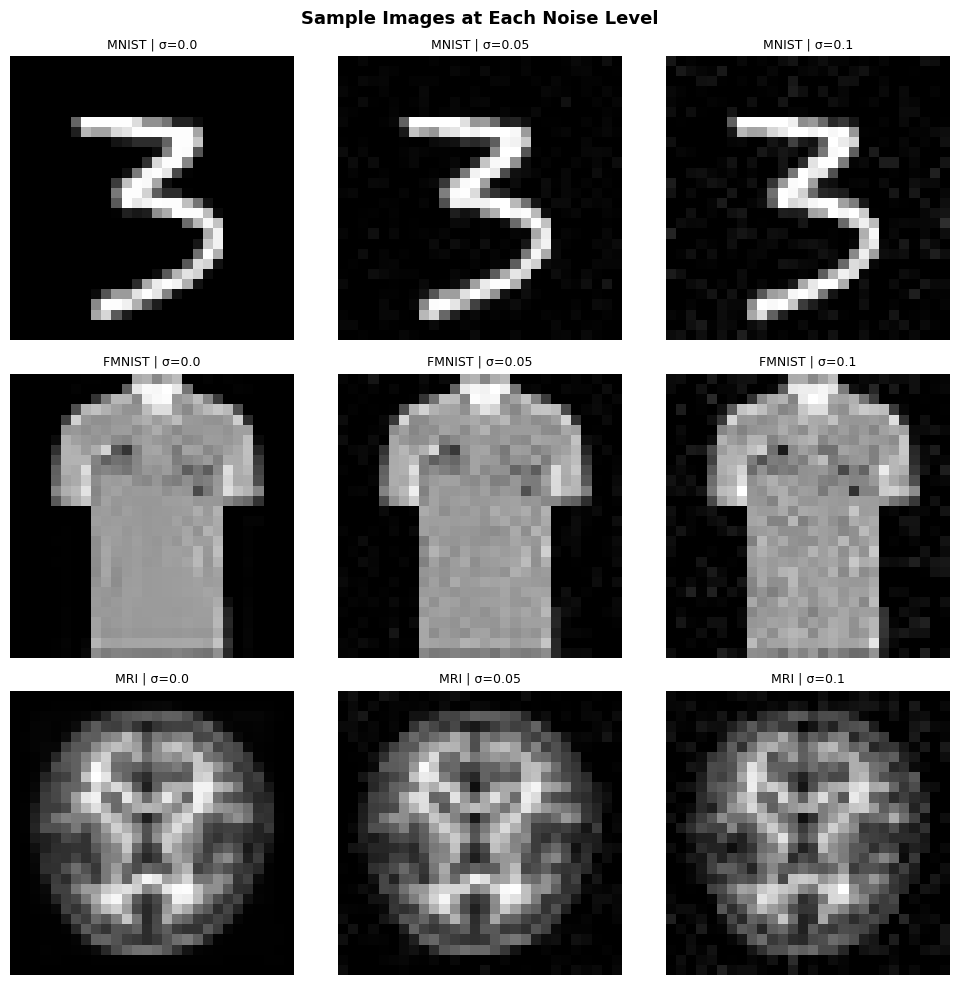

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('Sample Images at Each Noise Level', fontsize=13, fontweight='bold')

sample_loaders = {
    'MNIST':  mnist_loaders['test'],
    'FMNIST': fmnist_loaders['test'],
    'MRI':    mri_loaders['test'],
}
for row, (ds_name, loader) in enumerate(sample_loaders.items()):
    imgs, _ = next(iter(loader))
    for col, std in enumerate(NOISE_LEVELS):
        noisy = add_gaussian_noise(imgs[0:1], std)
        axes[row][col].imshow(noisy[0].squeeze().numpy(), cmap='gray')
        axes[row][col].set_title(f"{ds_name} | σ={std}", fontsize=9)
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('cnn_noise_samples.png', dpi=150, bbox_inches='tight')
plt.show()
